# 02 -- Подготовка данных и признаки

Здесь собираю каталог, делю запросы на части и описываю все признаки.
Сравню два набора: основные 80 полей и тот же набор с 21 дополнительным полем.
Некоторые признаки я добавил так: редкие слова учитываю сильнее общих, длинный список услуг
отличаю от точного заголовка, а расстояние использую без жесткого запрета других локаций.

Часть признаков относится к объявлению, часть -- к паре запрос--объявление.
Пары появятся после поиска кандидатов, поэтому здесь описываю их расчет, а модели вызывают
эти же функции на своих кандидатах. Формулы не дублирую по ноутбукам.

## Загрузка и нормализация

In [1]:
import hashlib

import json

import os

import re

import unicodedata

from pathlib import Path

import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent

QUERY_COLS = [
    'search_query',
    'search_location_id',
    'search_is_delivery_search',
    'search_infm_params_text',
    'search_category',
]


In [2]:
def normalize(value):
    if pd.isna(value):
        return ''
    text = unicodedata.normalize('NFKC', str(value)).lower().replace('ё', 'е')
    return ' '.join(re.findall(r'[\w]+', text))


In [3]:
def data_dir():
    path = Path(os.environ.get('AVITO_DATA_DIR', ROOT / 'dataset'))
    if not (path / 'train.parquet').exists():
        raise FileNotFoundError(
            f'Положите три Parquet в {path} или задайте AVITO_DATA_DIR'
        )
    return path


In [4]:
def load_raw():
    return tuple(
        pd.read_parquet(data_dir() / f'{name}.parquet')
        for name in ['train', 'benchmark_queries', 'benchmark_items']
    )


In [5]:
def query_keys(frame):
    """Полный контекст сохраняет различие фильтров; cold split группируется по тексту."""
    values = frame[QUERY_COLS].copy()
    for col in QUERY_COLS:
        values[col] = (
            values[col].map(normalize)
            if col in ['search_query', 'search_infm_params_text']
            else values[col].astype('string').fillna('<NA>')
        )
    return values.apply(
        lambda row: json.dumps(row.tolist(), ensure_ascii=False, separators=(',', ':')),
        axis=1,
    )


In [6]:
def prepare_queries(frame):
    result = frame[QUERY_COLS + (['query_id'] if 'query_id' in frame else [])].copy()
    result['text_key'] = result.search_query.map(normalize)
    result['context_key'] = query_keys(result)
    if 'query_id' not in result:
        result['query_id'] = result.context_key.map(
            lambda s: hashlib.sha256(s.encode()).hexdigest()[:24]
        )
    result['query_text'] = (
        result.text_key + ' ' + result.search_infm_params_text.map(normalize)
    )
    return result


In [7]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(8 << 20), b''):
            digest.update(chunk)
    return digest.hexdigest()


In [8]:
def write_json(value, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(
        json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding='utf-8'
    )


## Метрика и формат ответа

In [9]:
import csv

import re

from pathlib import Path

import numpy as np

import pandas as pd


In [10]:
def recall_table(predictions, truth, ks=(1, 10, 20, 50, 100)):
    rows = []
    for query_id, relevant in truth.items():
        relevant = set(relevant)
        if not relevant:
            raise ValueError(f'Пустая разметка: {query_id}')
        ranked = predictions.get(query_id, [])
        if len(ranked) != len(set(ranked)):
            raise ValueError(f'Повторы в выдаче: {query_id}')
        rows.append(
            {
                'query_id': query_id,
                'n_relevant': len(relevant),
                **{
                    f'recall@{k}': len(set(ranked[:k]) & relevant) / len(relevant)
                    for k in ks
                },
            }
        )
    if not rows:
        raise ValueError('Нет запросов для оценки')
    return pd.DataFrame(rows)


In [11]:
def bootstrap_ci(values, seed=143, repeats=2000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    means = [
        rng.choice(values, len(values), replace=True).mean() for _ in range(repeats)
    ]
    return np.quantile(means, [0.025, 0.975]).tolist()


In [12]:
def validate_submission(path, query_ids, item_ids):
    expected = list(query_ids)
    if len(set(expected)) != len(expected) or any(
        not isinstance(q, str) or len(q) != 16 for q in expected
    ):
        raise ValueError('Некорректные query_id в исходном benchmark')
    allowed = set(item_ids)
    if any(
        not isinstance(i, str) or re.fullmatch('[0-9a-f]{16}', i) is None
        for i in allowed
    ):
        raise ValueError('Некорректные item_id в исходном корпусе')
    with open(path, encoding='utf-8', newline='') as stream:
        reader = csv.reader(stream, strict=True)
        if next(reader, None) != ['query_id', 'answer']:
            raise ValueError('Ожидаются ровно query_id,answer в UTF-8 без BOM')
        rows = list(reader)
    seen = set()
    sizes = []
    for line, row in enumerate(rows, 2):
        if len(row) != 2:
            raise ValueError(f'Строка {line}: не две колонки')
        query_id, answer = row
        if query_id not in expected or query_id in seen:
            raise ValueError(f'Строка {line}: лишний или повторный query_id')
        seen.add(query_id)
        items = answer.split(' ') if answer else []
        if len(items) > 50 or len(set(items)) != len(items):
            raise ValueError(f'Строка {line}: >50 или повторные item_id')
        if any(
            re.fullmatch('[0-9a-f]{16}', item) is None or item not in allowed
            for item in items
        ):
            raise ValueError(f'Строка {line}: неправильный item_id или разделитель')
        sizes.append(len(items))
    if seen != set(expected):
        raise ValueError(f'Пропущено {len(set(expected) - seen)} query_id')
    return {
        'rows': len(rows),
        'min_candidates': min(sizes),
        'max_candidates': max(sizes),
        'valid': True,
    }


In [13]:
def save_submission(predictions, queries, items, path):
    if set(predictions) != set(queries.query_id):
        raise ValueError('Набор query_id предсказаний не совпадает с benchmark')
    frame = pd.DataFrame(
        {
            'query_id': queries.query_id,
            'answer': [' '.join(predictions[q]) for q in queries.query_id],
        }
    )
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, encoding='utf-8')
    return validate_submission(path, queries.query_id.tolist(), items.item_id.tolist())


## Признаки объявления и пары

In [14]:
import re

import numpy as np

import pandas as pd


In [15]:
def prepare_items(frame):
    items = frame.copy().reset_index(drop=True)
    for col in [
        'item_price',
        'item_latitude',
        'item_longitude',
        'item_rating',
        'item_rating_reviews_count',
    ]:
        items[col] = pd.to_numeric(items[col], errors='coerce').astype(float)
    for col, name in [
        ('item_title_raw', 'title_text'),
        ('item_infm_params_text', 'params_text'),
        ('item_description_raw', 'description_text'),
    ]:
        items[name] = items[col].map(normalize)
    # Lexical видит больше описания, dense укладывается в ограниченный token budget.
    items['lexical_text'] = (
        items.title_text
        + ' '
        + items.title_text
        + ' '
        + items.params_text.str[:800]
        + ' '
        + items.description_text.str[:2400]
    )
    items['dense_text'] = (
        items.title_text
        + '. '
        + items.params_text.str[:350]
        + '. '
        + items.description_text.str[:650]
    )
    return items


In [16]:
def item_features(items):
    result = pd.DataFrame(index=items.index)
    for col in ['item_price', 'item_rating_reviews_count']:
        value = pd.to_numeric(items[col], errors='coerce')
        result[f'{col}_missing'] = value.isna().astype('int8')
        if col == 'item_price':
            result['item_price_unknown'] = (value.isna() | value.lt(0)).astype('int8')
            value = value.where(value.ge(0))
        result[f'{col}_log1p'] = np.log1p(value.clip(lower=0))
        result[f'{col}_zero'] = value.eq(0).astype('int8')
    result['rating'] = items.item_rating
    result['rating_missing'] = items.item_rating.isna().astype('int8')
    reviews = items.item_rating_reviews_count.fillna(0).clip(lower=0)
    # Prior считается по каталогу, а не по выбранным пользователями объявлениям.
    prior = items.item_rating.median()
    result['rating_shrunk'] = (
        reviews * items.item_rating.fillna(prior) + 20 * prior
    ) / (reviews + 20)
    for col in ['title_text', 'params_text', 'description_text']:
        result[col + '_loglen'] = np.log1p(items[col].str.len())
        result[col + '_empty'] = items[col].eq('').astype('int8')
    result['phone_hidden'] = items.item_is_phone_hidden.astype('int8')
    result['message_forbidden'] = items.item_is_message_forbidden.astype('int8')
    result['both_contacts_restricted'] = result.phone_hidden * result.message_forbidden
    price = items.item_price.where(items.item_price.ge(0))
    median = price.groupby(items.item_microcat_id).transform('median')
    result['price_vs_microcat_log'] = np.log1p(price) - np.log1p(median)
    result['latitude'] = items.item_latitude.where(items.item_latitude.between(-90, 90))
    result['longitude'] = items.item_longitude.where(
        items.item_longitude.between(-180, 180)
    )
    return result.astype('float32')


In [17]:
def pair_features(query, positions, items, numeric, counts=None, centers=None):
    subset = items.iloc[positions]
    result = numeric.iloc[positions].reset_index(drop=True).copy()
    tokens = set(query.text_key.split())
    denom = max(1, len(tokens))
    for field in ['title_text', 'params_text', 'description_text']:
        result[field + '_coverage'] = [
            sum((' ' + t + ' ') in (' ' + x + ' ') for t in tokens) / denom
            for x in subset[field]
        ]
    result['query_tokens'] = len(tokens)
    result['query_chars'] = len(query.text_key)
    result['filter_chars'] = len(str(query.search_infm_params_text))
    result['same_location'] = (
        subset.item_location_id.eq(query.search_location_id).to_numpy().astype('int8')
    )
    result['same_category'] = (
        subset.item_category_id.eq(query.search_category).to_numpy().astype('int8')
    )
    result['delivery'] = int(query.search_is_delivery_search)
    result['item_pop_log'] = (
        np.log1p([counts.get(i, 0) for i in subset.item_id])
        if counts is not None
        else 0.0
    )
    result['distance_km_proxy'] = np.nan
    if centers is not None and query.search_location_id in centers.index:
        center = centers.loc[query.search_location_id]
        lat1, lon1 = np.radians([center.item_latitude, center.item_longitude])
        lat2 = np.radians(subset.item_latitude.to_numpy())
        lon2 = np.radians(subset.item_longitude.to_numpy())
        a = (
            np.sin((lat2 - lat1) / 2) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
        )
        result['distance_km_proxy'] = (
            6371.0088 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
        )
    match = re.search(
        r'(\d(?:[.,]\d)?)\s*звезд', str(query.search_infm_params_text).lower()
    )
    result['rating_threshold_requested'] = int(match is not None)
    result['rating_margin'] = (
        subset.item_rating.to_numpy() - float(match[1].replace(',', '.'))
        if match
        else np.nan
    )
    return result.replace([np.inf, -np.inf], np.nan).astype('float32')


In [18]:
def extra_features(frame, queries, items, idf, rank_columns=None):
    """Добавляю признаки без меток и без статистик отложенных выборов."""
    result = frame.copy()
    query_map = queries.set_index('query_id')
    titles = items.title_text.astype(object).to_numpy()
    params = items.params_text.astype(object).to_numpy()
    records = []

    for query_id, group in result.groupby('query_id', sort=False):
        query = query_map.loc[query_id]
        words = set(query.text_key.split())
        filters = set(normalize(query.search_infm_params_text).split())
        numbers = {word for word in words if any(char.isdigit() for char in word)}
        total_idf = sum(idf.get(word, 1.0) for word in words)

        for row in group.itertuples():
            title = titles[row.pos]
            title_words = set(title.split())
            param_words = set(params[row.pos].split())
            overlap = words & title_words
            records.append(
                {
                    'row': row.Index,
                    'title_jaccard': len(overlap) / max(1, len(words | title_words)),
                    'title_precision': len(overlap) / max(1, len(title_words)),
                    'title_idf_coverage': sum(idf.get(w, 1.0) for w in overlap)
                    / max(total_idf, 1.0),
                    'title_exact_phrase': int(
                        bool(query.text_key)
                        and (' ' + query.text_key + ' ') in (' ' + title + ' ')
                    ),
                    'title_extra_tokens': len(title_words - words),
                    'filter_param_coverage': len(filters & param_words)
                    / max(1, len(filters)),
                    'query_has_numbers': int(bool(numbers)),
                    'number_coverage': len(numbers & (title_words | param_words))
                    / max(1, len(numbers)),
                }
            )

    extra = pd.DataFrame(records).set_index('row').reindex(result.index)
    result = pd.concat([result, extra], axis=1)
    result['distance_log1p'] = np.log1p(result.distance_km_proxy.clip(lower=0))
    result['remote_distance'] = result.distance_log1p * (1 - result.same_location)
    result['dense_title_agreement'] = result.dense_cosine * result.title_text_coverage
    result['local_text_agreement'] = result.same_location * result.title_text_coverage
    result['rating_confidence'] = 1 - 1 / (
        1 + np.expm1(result.item_rating_reviews_count_log1p).clip(lower=0) / 20
    )

    if rank_columns is None:
        rank_columns = [col for col in frame if col.startswith('rank_')]
    # На инференсе использую тот же набор каналов, что при обучении.
    ranks = result.reindex(columns=rank_columns, fill_value=0)
    result['retriever_agreement'] = ranks.gt(0).sum(axis=1) / len(rank_columns)
    for name, tokens in [
        ('lexical', ['word', 'char', 'bm25']),
        ('semantic', ['dense', 'adapted']),
    ]:
        columns = [col for col in rank_columns if any(token in col for token in tokens)]
        result[f'{name}_best_rank'] = ranks[columns].max(axis=1)
    result['lexical_semantic_gap'] = (
        result.lexical_best_rank - result.semantic_best_rank
    )
    for name in ['dense_cosine', 'rrf', 'distance_km_proxy', 'item_price_log1p']:
        values = result.groupby('query_id')[name]
        result[f'{name}_pool_percentile'] = values.rank(
            pct=True, ascending=name != 'distance_km_proxy'
        )
    return result


## Работа с кандидатами

## Объединение кандидатов и матрица модели

In [19]:
import numpy as np

import pandas as pd


In [20]:
def candidate_features(
    candidates,
    queries,
    items,
    numeric,
    counts,
    weights,
    query_vectors=None,
    item_vectors=None,
    max_candidates=400,
    centers=None,
):
    pool = rrf(candidates, weights, constant=30, top_k=max_candidates)
    # Схема фиксируется по названиям, а не по случайно встретившимся в batch каналам.
    keys = pool[['query_id', 'pos']]
    selected = candidates.merge(keys, on=['query_id', 'pos'], how='inner')
    rank = selected.pivot_table(
        index=['query_id', 'pos'],
        columns='source',
        values='rank',
        aggfunc='min',
        observed=True,
    )
    rank = (1 / (30 + rank)).fillna(0).add_prefix('rank_')
    score = (
        selected.pivot_table(
            index=['query_id', 'pos'],
            columns='source',
            values='score',
            aggfunc='max',
            observed=True,
        )
        .fillna(0)
        .add_prefix('score_')
    )
    source_features = rank.join(score).reset_index()
    source_features['n_sources'] = (rank > 0).sum(axis=1).to_numpy()
    if centers is None:
        centers = items.groupby('item_location_id')[
            ['item_latitude', 'item_longitude']
        ].median()
    # Arrow chunked strings при многократном take могут копировать весь буфер.
    # Оставляю только нужные поля и один раз материализую строки для быстрых gather.
    pair_items = items[
        [
            'item_id',
            'title_text',
            'params_text',
            'description_text',
            'item_location_id',
            'item_category_id',
            'item_rating',
            'item_latitude',
            'item_longitude',
        ]
    ].copy()
    for col in ['item_id', 'title_text', 'params_text', 'description_text']:
        pair_items[col] = pair_items[col].astype(object)
    query_map = queries.set_index('query_id')
    frames = []
    for query_id, group in pool.groupby('query_id', sort=False):
        q = query_map.loc[query_id]
        positions = group.pos.to_numpy(dtype=int)
        features = pair_features(q, positions, pair_items, numeric, counts, centers)
        features['query_id'] = query_id
        features['pos'] = positions
        features['rrf'] = group.rrf.to_numpy()
        if query_vectors is not None and item_vectors is not None:
            features['dense_cosine'] = (
                np.asarray(item_vectors[positions]) @ query_vectors[query_id]
            )
        frames.append(features)
    result = pd.concat(frames, ignore_index=True).merge(
        source_features, on=['query_id', 'pos'], how='left'
    )
    return result


In [21]:
def feature_columns(frame):
    return [
        c
        for c in frame
        if c not in ['query_id', 'pos', 'target', 'regime', 'split', 'item_id']
    ]


In [22]:
def model_matrix(frame, columns):
    # Источник может не вернуть ни одного кандидата для batch: missing rank/score = 0.
    result = frame.reindex(columns=columns).copy()
    for col in columns:
        if col.startswith(('rank_', 'score_')) or col == 'n_sources':
            result[col] = result[col].fillna(0)
    return result.fillna(-1).astype('float32')


In [23]:
from collections import defaultdict

from pathlib import Path

import json

import time

import numpy as np

import pandas as pd

from scipy import sparse

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfTransformer,
    TfidfVectorizer,
)

from sklearn.naive_bayes import MultinomialNB


In [24]:
def rrf(candidates, weights=None, constant=30, top_k=100):
    frame = candidates.copy()
    weights = (
        weights if weights is not None else {s: 1.0 for s in frame.source.unique()}
    )
    frame['rrf'] = frame.source.map(weights).fillna(0) / (constant + frame['rank'])
    frame = (
        frame[frame.rrf.gt(0)].groupby(['query_id', 'pos'], as_index=False).rrf.sum()
    )
    return (
        frame.sort_values(['query_id', 'rrf', 'pos'], ascending=[True, False, True])
        .groupby('query_id', sort=False)
        .head(top_k)
    )


In [25]:
def predictions_from_frame(frame, items, score=None, k=100):
    if score is not None:
        frame = frame.sort_values(
            ['query_id', score, 'pos'], ascending=[True, False, True]
        )
    frame = (
        frame.drop_duplicates(['query_id', 'pos'])
        .groupby('query_id', sort=False)
        .head(k)
    )
    ids = items.item_id.to_numpy()
    frame = frame.assign(item_id=ids[frame.pos.to_numpy(dtype=int)])
    return frame.groupby('query_id', sort=False).item_id.agg(list).to_dict()


In [26]:
def dense_search(query_vectors, item_vectors, queries, items, k=120, batch_size=16):
    rows = []
    locations = items.item_location_id.to_numpy()
    for start in range(0, len(queries), batch_size):
        scores = (
            np.asarray(query_vectors[start : start + batch_size], dtype=np.float32)
            @ np.asarray(item_vectors, dtype=np.float32).T
        )
        for offset, values in enumerate(scores):
            q = queries.iloc[start + offset]
            for source, allowed in [
                ('dense', None),
                ('dense_local', np.flatnonzero(locations == q.search_location_id)),
            ]:
                positions = top_indices(values, k, allowed)
                rows.extend(
                    (q.query_id, int(p), source, rank + 1, float(values[p]))
                    for rank, p in enumerate(positions)
                )
    return compact_candidates(
        pd.DataFrame(rows, columns=['query_id', 'pos', 'source', 'rank', 'score'])
    )


In [27]:
def compact_candidates(frame):
    return frame.astype(
        {
            'query_id': 'string',
            'pos': 'int32',
            'source': 'category',
            'rank': 'int16',
            'score': 'float32',
        }
    )


## Загрузка и каталог

Сначала считаю признаки объявлений. Использую известный каталог без меток выбора пользователя.
Все случайные операции ниже используют seed 143.

In [28]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

fe_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent

fe_out = fe_root / 'outputs'
fe_seed = 143

for fe_folder in ['cache', 'models', 'validation', 'figures', 'submissions']:
    (fe_out / fe_folder).mkdir(parents=True, exist_ok=True)


In [29]:
import hashlib

fe_train, fe_queries, fe_benchmark = load_raw()
fe_q = prepare_queries(fe_train)
fe_pairs = fe_q.copy()
fe_pairs['item_id'] = fe_train.item_id.to_numpy()
fe_pairs = fe_pairs.drop_duplicates(['context_key', 'item_id']).reset_index(drop=True)
fe_catalog = (
    pd.concat(
        [fe_benchmark, fe_train[[c for c in fe_train if c.startswith('item_')]]],
        ignore_index=True,
    )
    .drop_duplicates('item_id')
    .sort_values('item_id')
    .reset_index(drop=True)
)
assert fe_catalog.item_id.is_unique


In [30]:
fe_items = prepare_items(fe_catalog)
fe_numeric = item_features(fe_items)
fe_items.to_parquet(fe_out / 'cache/items.parquet', index=False)
fe_numeric.to_parquet(fe_out / 'cache/item_features.parquet', index=False)
fe_bq = prepare_queries(fe_queries)
fe_bq.to_parquet(fe_out / 'cache/benchmark_queries.parquet', index=False)
display(fe_numeric.describe().T)


,count,mean,std,min,25%,50%,75%,max
item_price_missing,515895.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
item_price_unknown,515895.0,0.073750,0.261363,0.000000,0.000000,0.000000,0.000000,1.000000
item_price_log1p,477848.0,6.882732,1.831001,0.000000,6.216606,6.908755,7.824446,27.631021
item_price_zero,515895.0,0.008686,0.092792,0.000000,0.000000,0.000000,0.000000,1.000000
item_rating_reviews_count_missing,515895.0,0.052133,0.222295,0.000000,0.000000,0.000000,0.000000,1.000000
item_rating_reviews_count_log1p,489000.0,3.032036,1.494951,0.000000,1.945910,2.995732,4.043051,9.814219
item_rating_reviews_count_zero,515895.0,0.024408,0.154313,0.000000,0.000000,0.000000,0.000000,1.000000
rating,475607.0,4.793191,0.721136,0.000000,4.875000,5.000000,5.000000,5.000000
rating_missing,515895.0,0.078093,0.268319,0.000000,0.000000,0.000000,0.000000,1.000000
rating_shrunk,515895.0,4.951576,0.096036,3.281482,4.934783,5.000000,5.000000,5.000000


## Как я добавляю признаки

| Группа | Признаки | Зачем |
|---|---|---|
| Текст | отдельные title, params, description; длины и пустота | короткий заголовок точнее, описание полнее |
| Цена | log1p, 0, missing/служебная -1, отклонение от медианы microcategory | сопоставлять цену внутри типа услуг |
| Репутация | рейтинг, log reviews, missing, сглаженный рейтинг | пять звезд при одном отзыве не равны пяти при тысяче |
| Контакт | hidden phone, forbidden messages, оба флага | доступность способов связи, без жесткого исключения |
| Query--item | покрытие слов по каждому полю, совпадения location/category | релевантность и контекст |
| География | haversine до медианного центра location из каталога | только приблизительная дистанция; координат запроса нет |
| Фильтры | длина, запрошенный порог рейтинга, запас до порога | разделяю «не проходит» и «неизвестно» |
| Поведение | популярность, история текста/контекста, похожие запросы | только на разрешенной обучающей части |

Нормализация: Unicode NFKC, lower, замена U+0451 на U+0435, пробелы. Числа сохраняются. Не транслитерирую
все подряд, не выкидываю отрицания. Символьный поиск компенсирует часть морфологии.

## Warm и cold без повторения полного контекста

`cold`: целиком отложенный нормализованный текст со всеми контекстами.
`warm`: целиком отложенный контекст (текст + все фильтры + локация) знакомого текста.
Один и тот же полный контекст не встречается в base. Исторический выбор того же item
по другому контексту допустим: это доступный behavioral сигнал. Отдельно публикую долю
новых (text, item) и Recall на них: общий warm score может быть оптимистичнее cold.
Проверка только новых пар сделала бы history всегда ошибочным и обучила fusion подавлять его.

Тексты `rank_train`, `dev`, `test` не пересекаются друг с другом. У warm есть другие контексты
в base. `dev` выбирает модель и параметры, `test` использую для отдельной проверки после выбора. Он уже открывался в предыдущих экспериментах, поэтому свежим независимым тестом его не считаю.
Выбираю не больше одного контекста на текст: в benchmark тексты тоже уникальны.
Полный список отложенных пар сохраняется; выборка для оценки не возвращает остальные пары в base.

In [31]:
def fe_hash(value):
    return int(hashlib.sha256(('143|' + value).encode()).hexdigest()[:16], 16)


fe_texts = fe_pairs.text_key.drop_duplicates()
fe_text_hash = fe_texts.map(fe_hash)
fe_role_by_text = dict(
    zip(fe_texts, fe_text_hash.map(lambda h: ['rank_train', 'dev', 'test'][h % 3]))
)
fe_cold_by_text = dict(zip(fe_texts, fe_text_hash.map(lambda h: (h // 3) % 100 < 15)))
fe_hold_pair = fe_pairs.context_key.map(fe_hash).mod(5).eq(0)
fe_is_cold = fe_pairs.text_key.map(fe_cold_by_text)
fe_role = fe_pairs.text_key.map(fe_role_by_text)
fe_has_base = set(fe_pairs.loc[~fe_is_cold & ~fe_hold_pair, 'text_key'])
fe_is_warm = ~fe_is_cold & fe_hold_pair & fe_pairs.text_key.isin(fe_has_base)
fe_pairs['split'] = np.where(fe_is_cold | fe_is_warm, fe_role, 'base')
fe_pairs['regime'] = np.where(fe_is_cold, 'cold', 'warm')
fe_base = fe_pairs[fe_pairs.split.eq('base')].copy()
fe_eval = []
for fe_split, fe_limit in [('rank_train', 2200), ('dev', 1000), ('test', 1000)]:
    for fe_regime in ['warm', 'cold']:
        fe_part = fe_pairs[fe_pairs.split.eq(fe_split) & fe_pairs.regime.eq(fe_regime)]
        fe_contexts = fe_part.drop_duplicates('context_key').sort_values('context_key')
        fe_contexts = (
            fe_contexts.sample(frac=1, random_state=fe_seed)
            .drop_duplicates('text_key')
            .head(fe_limit)
        )
        fe_eval.append(fe_contexts)


In [32]:
fe_eval = pd.concat(fe_eval, ignore_index=True)
assert fe_eval.query_id.is_unique
assert not set(fe_base.text_key) & set(
    fe_eval.loc[fe_eval.regime.eq('cold'), 'text_key']
)
assert set(fe_eval.loc[fe_eval.regime.eq('warm'), 'text_key']) <= set(fe_base.text_key)
assert not set(fe_base.context_key) & set(
    fe_pairs.loc[fe_pairs.split.ne('base'), 'context_key']
)
assert not set(zip(fe_base.context_key, fe_base.item_id)) & set(
    zip(
        fe_pairs.loc[fe_pairs.split.ne('base'), 'context_key'],
        fe_pairs.loc[fe_pairs.split.ne('base'), 'item_id'],
    )
)
for fe_a, fe_b in [('rank_train', 'dev'), ('rank_train', 'test'), ('dev', 'test')]:
    assert not set(fe_eval.loc[fe_eval.split.eq(fe_a), 'text_key']) & set(
        fe_eval.loc[fe_eval.split.eq(fe_b), 'text_key']
    )
fe_truth_rows = fe_pairs[
    fe_pairs.query_id.isin(fe_eval.query_id) & fe_pairs.split.ne('base')
]
fe_truth = (
    fe_truth_rows.groupby('query_id').item_id.agg(lambda s: sorted(set(s))).to_dict()
)
fe_allowed = set(fe_items.item_id)
assert all(set(v) <= fe_allowed for v in fe_truth.values())
fe_pairs.to_parquet(fe_out / 'cache/split_pairs.parquet', index=False)


In [33]:
fe_base.to_parquet(fe_out / 'cache/base_pairs.parquet', index=False)
fe_eval.drop(columns='item_id').to_parquet(
    fe_out / 'cache/eval_queries.parquet', index=False
)
write_json(fe_truth, fe_out / 'cache/truth.json')
fe_split_summary = fe_eval.groupby(['split', 'regime']).agg(
    queries=('query_id', 'size')
)
display(fe_split_summary)
fe_split_summary.to_csv(fe_out / 'validation/split_summary.csv')
write_json(
    {
        'catalog_items': len(fe_items),
        'base_pairs': len(fe_base),
        'all_unique_pairs': len(fe_pairs),
        'evaluation_queries': len(fe_eval),
        'context_item_overlap': 0,
        'cold_text_overlap': 0,
        'test_used_for_selection': False,
        'seed': fe_seed,
    },
    fe_out / 'validation/leakage_audit.json',
)


queries
split      regime         
dev        cold       1000
           warm       1000
rank_train cold       2200
           warm       2200
test       cold       1000
           warm       1000

In [34]:
fe_diagnostics = fe_eval[['query_id', 'split', 'regime', 'text_key']].copy()
fe_diagnostics['n_relevant'] = fe_diagnostics.query_id.map(lambda q: len(fe_truth[q]))
fe_seen_items = set(fe_base.item_id)
fe_diagnostics['cold_item_fraction'] = fe_diagnostics.query_id.map(
    lambda q: np.mean([i not in fe_seen_items for i in fe_truth[q]])
)
fe_text_items = fe_base.groupby('text_key').item_id.agg(set).to_dict()
fe_diagnostics['new_pair_fraction'] = [
    np.mean([i not in fe_text_items.get(t, set()) for i in fe_truth[q]])
    for q, t in zip(fe_diagnostics.query_id, fe_diagnostics.text_key)
]
fe_diagnostics['query_train_frequency'] = fe_diagnostics.text_key.map(
    fe_base.text_key.value_counts()
).fillna(0)
fe_diagnostics.to_parquet(fe_out / 'validation/query_slices.parquet', index=False)
display(
    fe_diagnostics.groupby(['split', 'regime'])[
        ['n_relevant', 'cold_item_fraction', 'query_train_frequency']
    ].mean()
)
fe_numeric.corr(method='spearman').to_csv(
    fe_out / 'validation/engineered_correlations.csv'
)


n_relevant  cold_item_fraction  query_train_frequency
split      regime                                                       
dev        cold      1.116000            0.685856                  0.000
           warm      1.155000            0.668238                 50.052
rank_train cold      1.076818            0.694183                  0.000
           warm      1.142727            0.659534                 33.645
test       cold      1.071000            0.665708                  0.000
           warm      1.207000            0.663434                 62.939

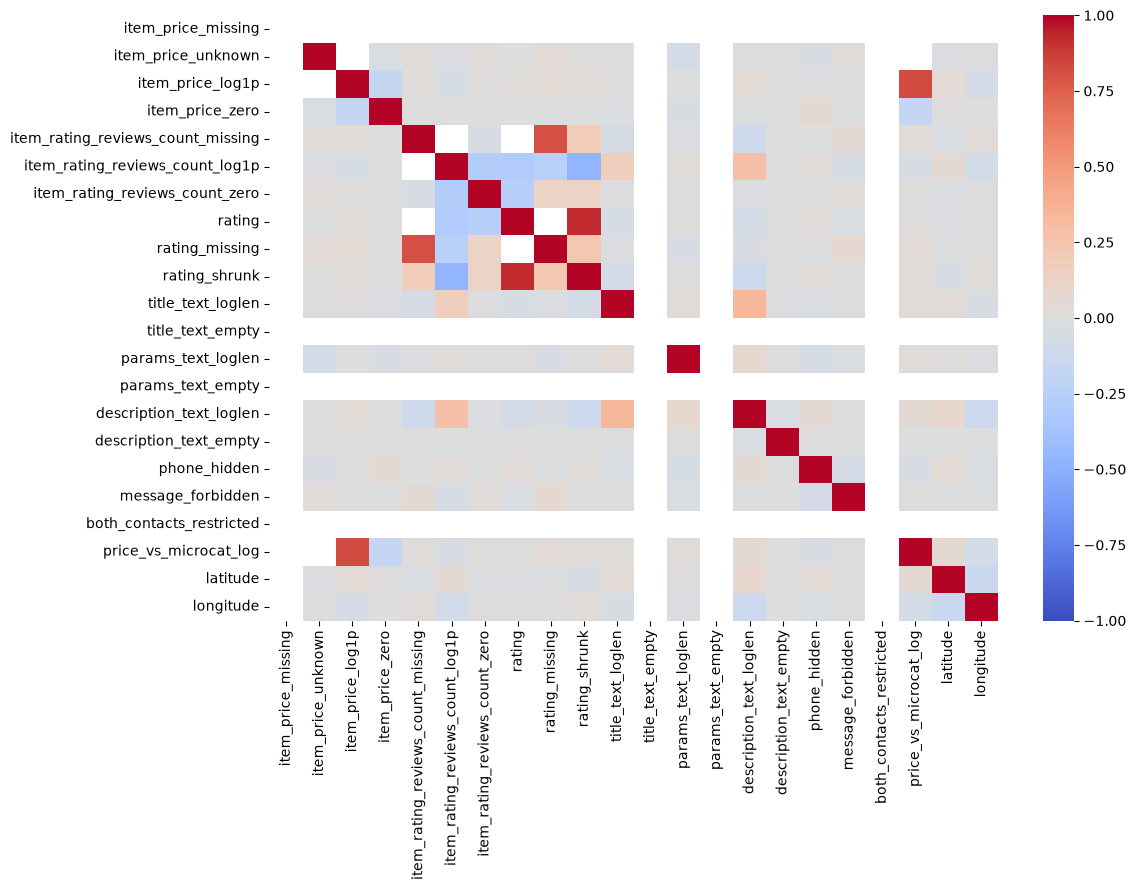

In [35]:
plt.figure(figsize=(12, 9))
import seaborn as sns

sns.heatmap(
    fe_numeric.corr(method='spearman'), cmap='coolwarm', center=0, vmin=-1, vmax=1
)

plt.tight_layout()
plt.savefig(fe_out / 'figures/engineered_correlations.png', dpi=150)
plt.show()


## Ограничения протокола

Полный локальный корпус больше финального, поэтому задача поиска локально сложнее по числу distractors.
С другой стороны, его состав получен из positive-only train, а не случайной выгрузки всей площадки.
Warm/cold результаты публикую отдельно; среднее не выдаю за leaderboard score.
Даже этот split не проверяет временную устойчивость: времени в данных нет.
Признаки меняющихся объявлений -- статический snapshot, поэтому временную утечку исключить невозможно.

## Веса редких слов

Считаю IDF по заголовкам каталога. Для этого не нужны положительные пары.
Например, совпадение «видеодомофон» обычно полезнее совпадения «услуги».

In [36]:
from collections import Counter

fe_df = Counter()
for fe_title in fe_items.title_text:
    fe_df.update(set(fe_title.split()))
fe_idf = {
    word: float(np.log1p(len(fe_items) / (1 + count))) for word, count in fe_df.items()
}
write_json(fe_idf, fe_out / 'models/title_idf.json')


## Что проверяю перед обучением

Полный контекст не пересекает base и отложенные части. Cold-текст целиком отсутствует в base.
Категории и локации не считаю непрерывными числами. Цена -1 -- неизвестная цена, а не бесплатная услуга.
Список retrieval-каналов фиксирую по обучению: появление нового канала не должно менять
знаменатель признака согласия источников.

In [37]:
assert (
    recall_table(
        {'a': ['x'], 'b': ['z']}, {'a': ['x', 'y'], 'b': ['z'], 'c': ['v']}, ks=(50,)
    )['recall@50'].mean()
    == 0.5
)
assert fe_numeric.loc[fe_items.item_price.lt(0), 'item_price_unknown'].eq(1).all()
assert not np.isinf(fe_numeric.to_numpy()).any()
print('Разбиения, метрика и признаки проверены')


Разбиения, метрика и признаки проверены
